In [85]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix


import warnings
warnings.filterwarnings('ignore')

In [86]:
df = pd.read_pickle("cleaned_online_retail.pkl")
print(df.shape)
df.head()

(406309, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# **STEP 3 : FEATURE ENGINEERING**

In [87]:
# adding a new feature as 'Sales'
df['Sales'] = df['Quantity'] * df['Price']
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [88]:
# creating a new df with unique coustomer id
unique_df = df.groupby(by="Customer ID", as_index=False).agg(
        TotalSale = ("Sales", "sum"),
        Frequency = ("Invoice", "nunique"),
        LastInvoiceDate = ("InvoiceDate", "max")
    )


# as_index = False means we dont want to make customer id as index

unique_df.head()

,Customer ID,TotalSale,Frequency,LastInvoiceDate
0,12346.0,169.36,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,2221.14,2,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00


In [89]:
# copying the unique_df into a new dataframe 

data = unique_df.copy()

unique_df.describe()

,Customer ID,TotalSale,Frequency,LastInvoiceDate
count,4285.000000,4285.000000,4285.000000,4285
mean,15356.806768,2024.126801,4.426138,2010-09-11 00:06:10.431738624
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00
25%,13891.000000,307.560000,1.000000,2010-07-27 14:39:00
50%,15362.000000,702.900000,2.000000,2010-10-19 12:10:00
75%,16840.000000,1704.290000,5.000000,2010-11-22 11:24:00
max,18287.000000,349164.350000,183.000000,2010-12-09 20:01:00
std,1699.839258,8813.945538,7.938017,NaN


In [90]:
# finding day and month from the newest date in the data

oldest_invoice_date = data['LastInvoiceDate'].max()

print("OLDERST DATE : ", oldest_invoice_date)
print()

delta = oldest_invoice_date - data['LastInvoiceDate']

# 1. Total Days
data['RecencyInDays'] = delta.dt.days

# 2. Total Months (Approximate: 30.44 days per month)
data['RecencyInMonths'] = delta.dt.days / 30.44

# 3. Total Years (Approximate: 365.25 days per year)
# data['RecencyInYears'] = delta.dt.days / 365.25

# print(data['RecencyInYears'].max())

data.head()


OLDERST DATE :  2010-12-09 20:01:00



,Customer ID,TotalSale,Frequency,LastInvoiceDate,RecencyInDays,RecencyInMonths
0,12346.0,169.36,2,2010-06-28 13:53:00,164,5.387648
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,0.065703
2,12348.0,221.16,1,2010-09-27 14:59:00,73,2.398160
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,1.379763
4,12351.0,300.93,1,2010-11-29 15:23:00,10,0.328515


In [91]:
# finding the days and months of the data based on todays date

today = pd.to_datetime('today')

data['RecencyInDays'] = (today - data['LastInvoiceDate']).dt.days
data['RecencyInMonths'] = ((today - data['LastInvoiceDate']).dt.days / 30.44).astype(int)
data['RecencyInYears'] = ((today - data['LastInvoiceDate']).dt.days / 365.25).astype(int)

data.head(10)

,Customer ID,TotalSale,Frequency,LastInvoiceDate,RecencyInDays,RecencyInMonths,RecencyInYears
0,12346.0,169.36,2,2010-06-28 13:53:00,5710,187,15
1,12347.0,1323.32,2,2010-12-07 14:57:00,5548,182,15
2,12348.0,221.16,1,2010-09-27 14:59:00,5619,184,15
3,12349.0,2221.14,2,2010-10-28 08:23:00,5588,183,15
4,12351.0,300.93,1,2010-11-29 15:23:00,5556,182,15
5,12352.0,343.80,2,2010-11-29 10:07:00,5556,182,15
6,12353.0,317.76,1,2010-10-27 12:44:00,5589,183,15
7,12355.0,488.21,1,2010-05-21 11:59:00,5748,188,15
8,12356.0,3126.25,3,2010-11-24 12:24:00,5561,182,15
9,12357.0,11229.99,1,2010-11-16 10:05:00,5569,182,15


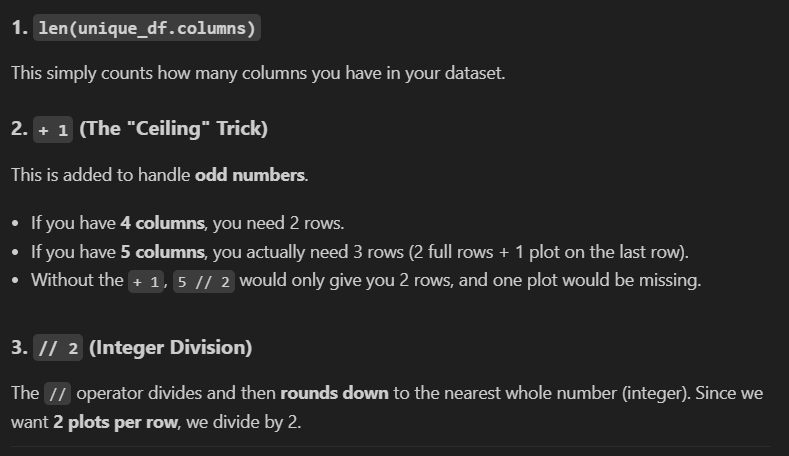

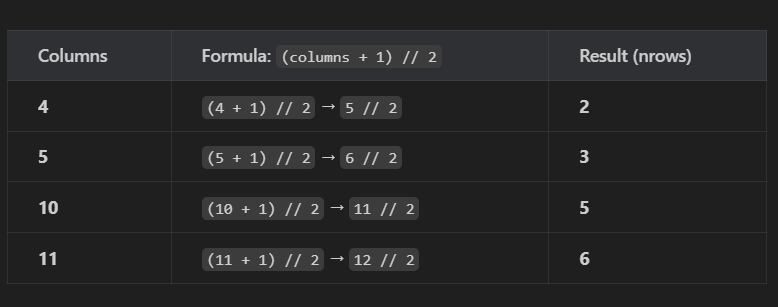

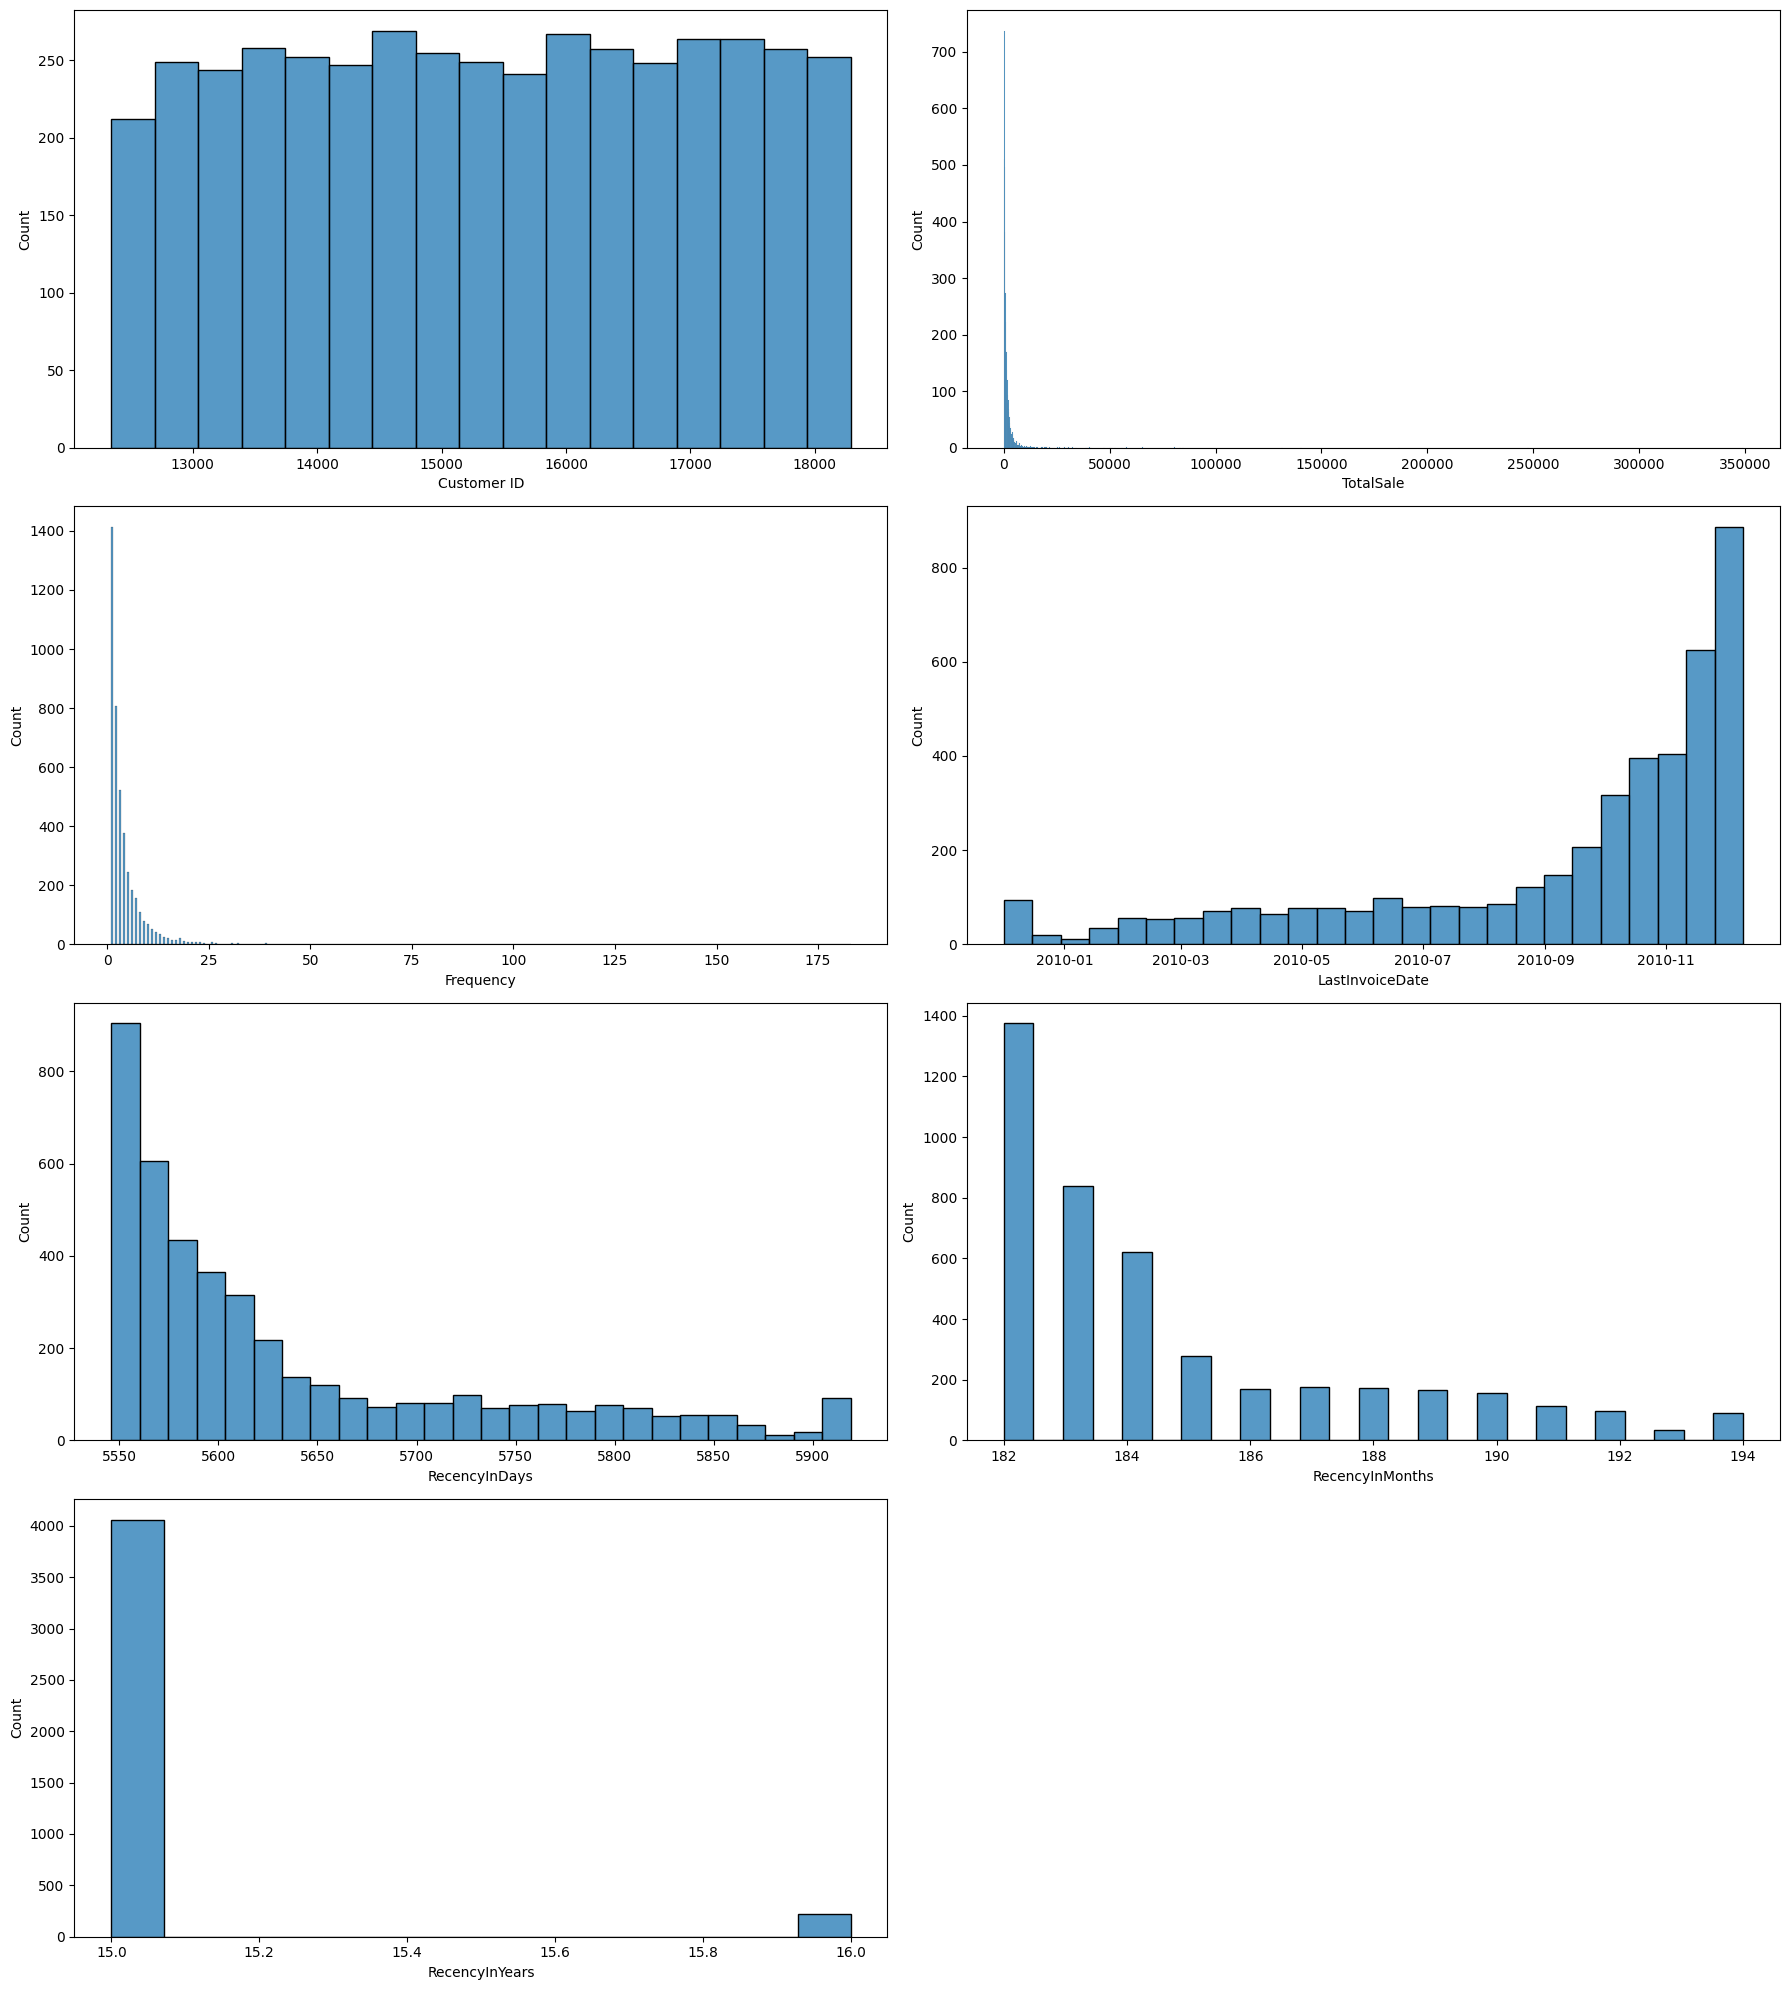

In [92]:
# plotting the data

# Calculating how many rows we need if we want 2 columns
ncols = 2
nrows = (len(data.columns) + 1) // 2 

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))

# Using ravel() to flatten the 2D grid of axes into a 1D list so we can loop over it
axes = axes.ravel() 

for i, col in enumerate(data.columns):
    sns.histplot(data[col], ax=axes[i]) # Tells seaborn which subplot to use
    plt.xlabel(col)
    plt.ylabel('Count')
    
# If you have an odd number of columns, delete the empty plot space at the end
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

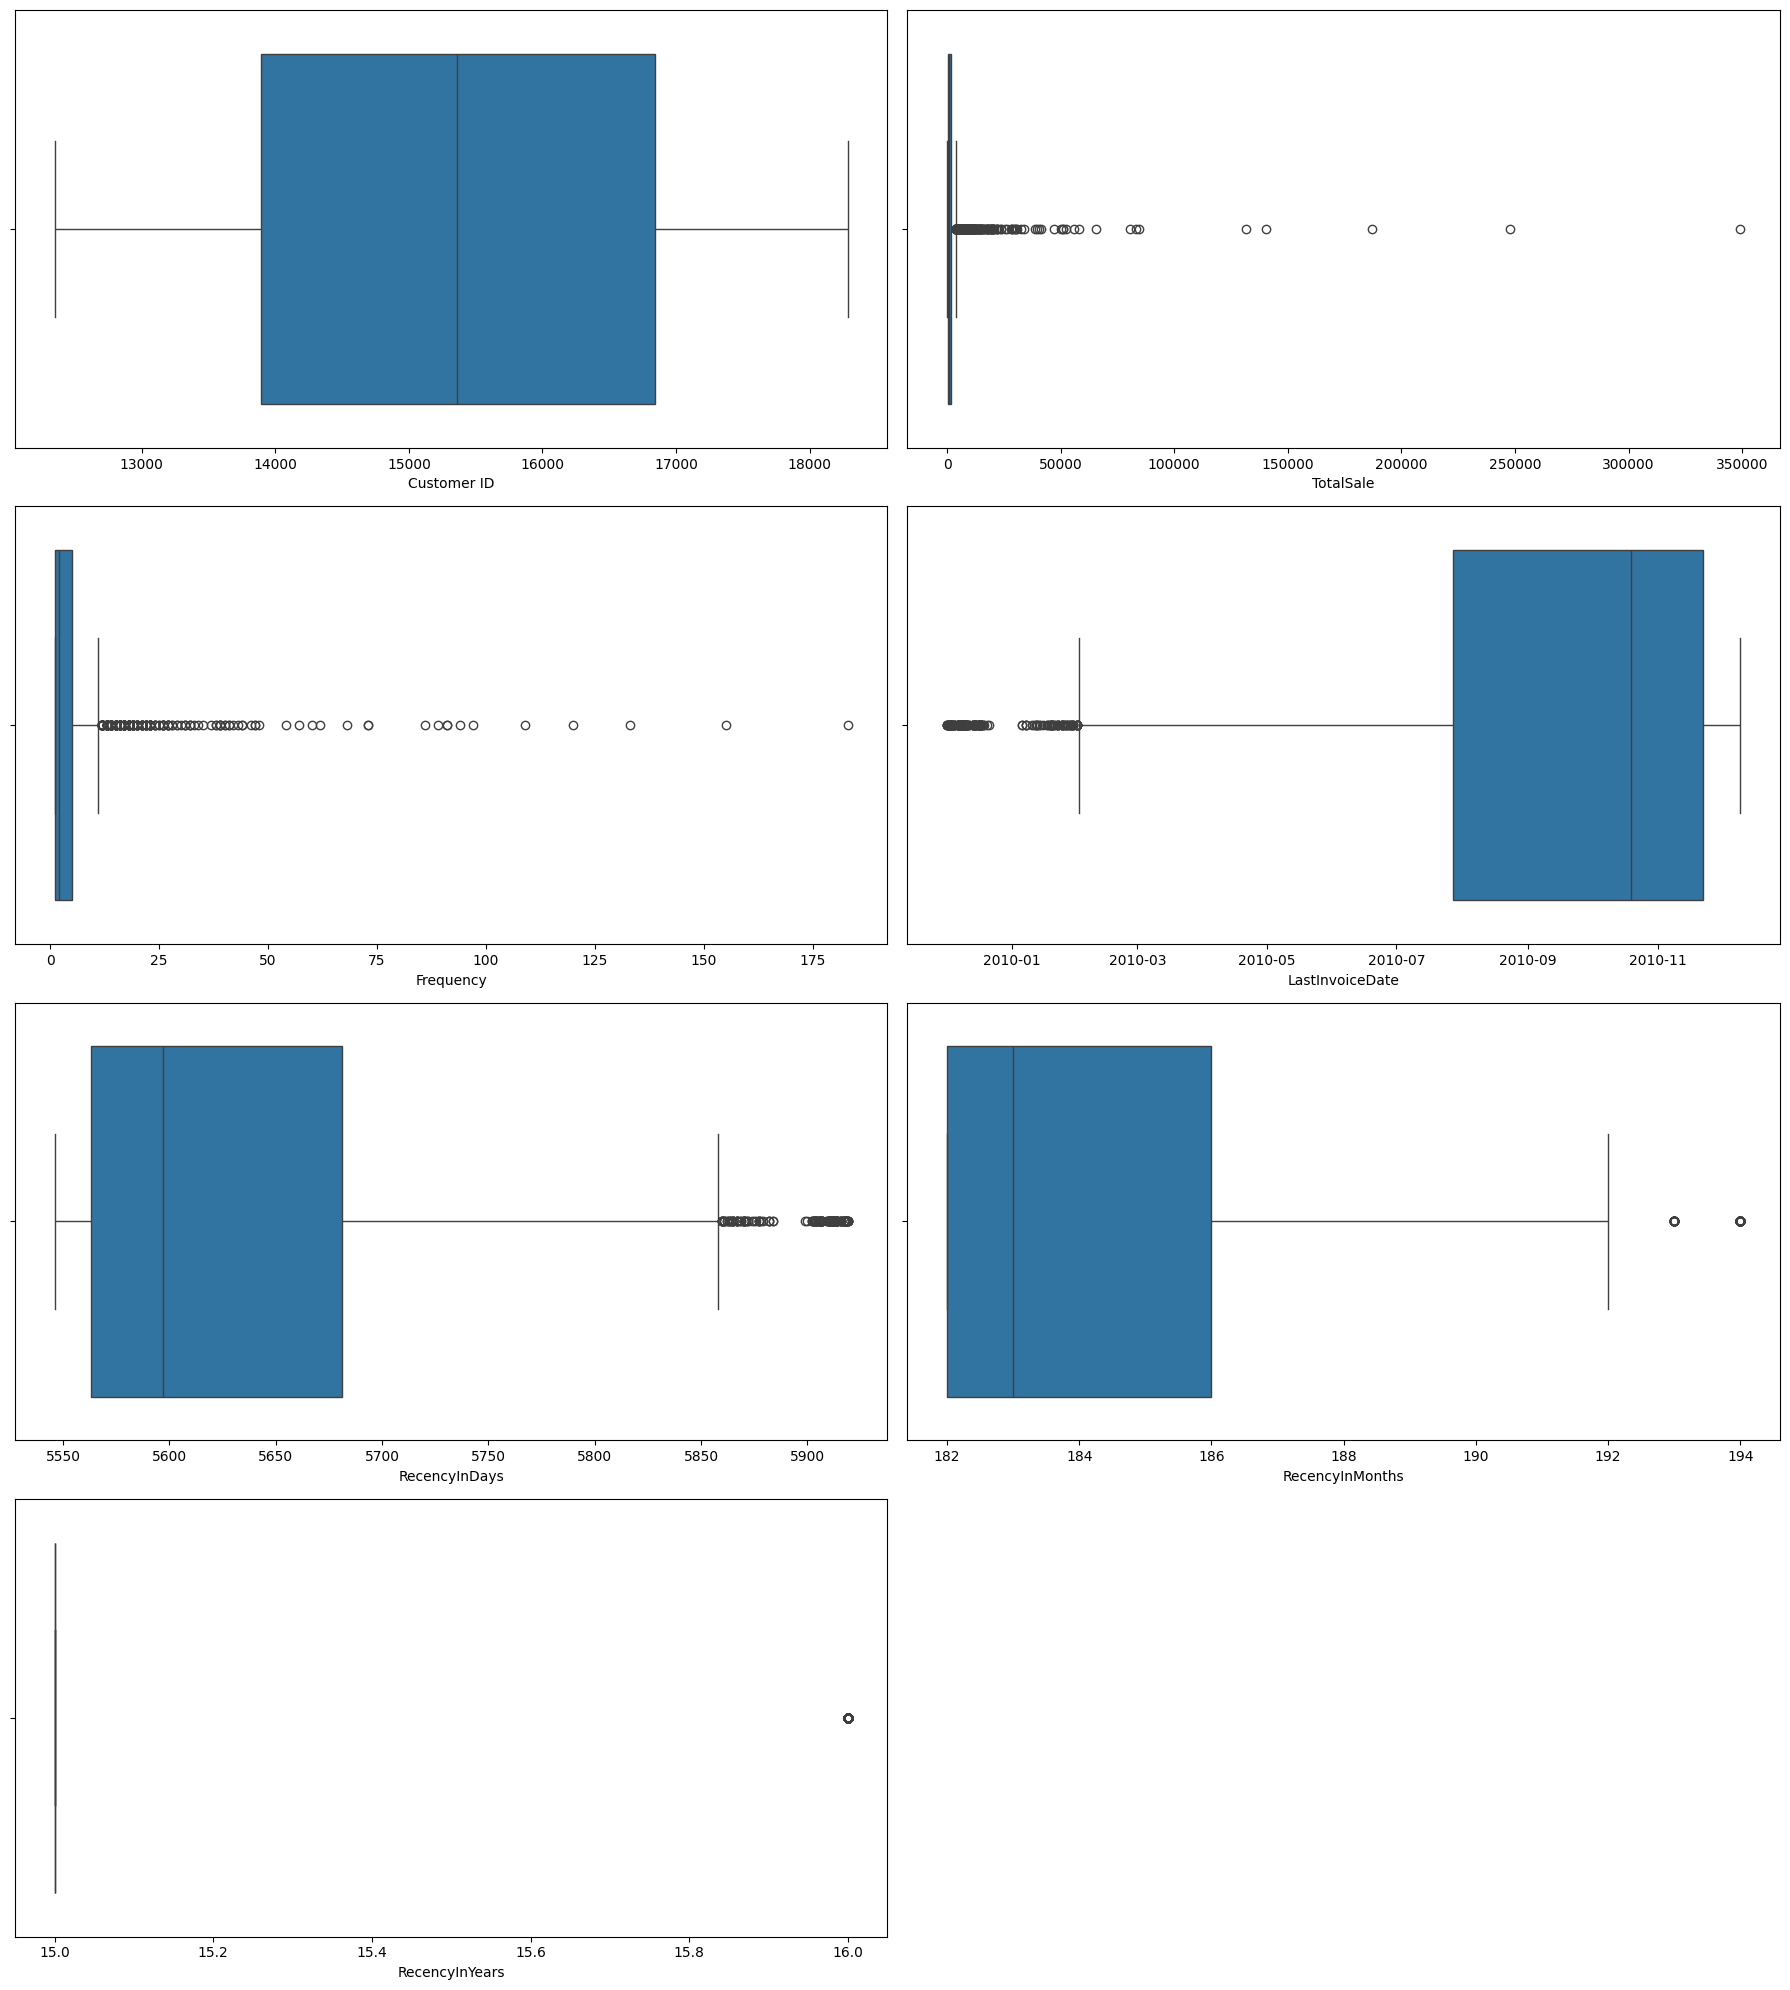

In [93]:
# plotting the data

# Calculating how many rows we need if we want 2 columns
ncols = 2
nrows = (len(data.columns) + 1) // 2 

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 5))

# Using ravel() to flatten the 2D grid of axes into a 1D list so we can loop over it
axes = axes.ravel() 

for i, col in enumerate(data.columns):
    sns.boxplot(x=data[col], ax=axes[i]) # Tells seaborn which subplot to use
    plt.xlabel(col)
    plt.ylabel('Count')
    
# If you have an odd number of columns, delete the empty plot space at the end
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [94]:
# using IQR method to deal with outliers

for i in data.columns:
    if (i == 'Customer ID') | (i == 'LastInvoiceDate'):
        continue

    q1 = data[i].quantile(0.25)
    q3 = data[i].quantile(0.75)
    iqr = q3 - q1

    upper_limit = q3 + 1.5 * iqr
    lower_limit = q1 - 1.5 * iqr
    # Filter the data
    outliers = data[(data[i] > upper_limit) | (data[i] < lower_limit)]

    print(f"TOTAL OUTLIERS IN {i} : ", outliers.shape[0])
    print(f"mean : {outliers[i].mean().astype(int)}")
    print(f"std : {outliers[i].std().astype(int)}")
    print(f"count : {outliers[i].count()}")
    print(f"min : {outliers[i].min()}")
    print(f"max : {outliers[i].max()}")
    print(f"q1 : {outliers[i].quantile(0.25)}")
    print(f"q3 : {outliers[i].quantile(0.75)}")
    print(f"iqr : {outliers[i].quantile(0.50)}")
    print("-------------------------------------------------------------")



TOTAL OUTLIERS IN TotalSale :  423
mean : 12188
std : 25830
count : 423
min : 3802.04
max : 349164.35
q1 : 4605.94
q3 : 10273.235
iqr : 6191.32
-------------------------------------------------------------
TOTAL OUTLIERS IN Frequency :  279
mean : 23
std : 21
count : 279
min : 12
max : 183
q1 : 13.0
q3 : 23.0
iqr : 17.0
-------------------------------------------------------------
TOTAL OUTLIERS IN RecencyInDays :  167
mean : 5896
std : 20
count : 167
min : 5860
max : 5919
q1 : 5874.5
q3 : 5913.0
iqr : 5906.0
-------------------------------------------------------------
TOTAL OUTLIERS IN RecencyInMonths :  125
mean : 193
std : 0
count : 125
min : 193
max : 194
q1 : 193.0
q3 : 194.0
iqr : 194.0
-------------------------------------------------------------
TOTAL OUTLIERS IN RecencyInYears :  225
mean : 16
std : 0
count : 225
min : 16
max : 16
q1 : 16.0
q3 : 16.0
iqr : 16.0
-------------------------------------------------------------


In [95]:
# from above we learned that we will be removing outliers only from TotalSale and Frequency


q1 = data['TotalSale'].quantile(0.25)
q3 = data['TotalSale'].quantile(0.75)
iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr


outliers_sale = data[(data['TotalSale'] > upper_limit) | (data['TotalSale'] < lower_limit)]

# ************************************************************************************************************************

q1 = data['Frequency'].quantile(0.25)
q3 = data['Frequency'].quantile(0.75)
iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr
lower_limit = q1 - 1.5 * iqr


outliers_frequency = data[(data['Frequency'] > upper_limit) | (data['Frequency'] < lower_limit)]

print(outliers_sale.shape)
print(outliers_frequency.shape)


(423, 7)
(279, 7)


In [ ]:
# checking for non-outlier datas

non_outliers = data[(~data.index.isin(outliers_sale.index)) & ((~data.index.isin(outliers_frequency.index)))] 

print(non_outliers.shape[0])
non_outliers.describe()

3809


,Customer ID,TotalSale,Frequency,LastInvoiceDate,RecencyInDays,RecencyInMonths,RecencyInYears
count,3809.000000,3809.000000,3809.000000,3809,3809.000000,3809.00000,3809.000000
mean,15376.482804,885.502197,2.863481,2010-09-03 11:16:46.516146176,5643.082961,184.89446,15.058283
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00,5546.000000,182.00000,15.000000
25%,13912.000000,279.910000,1.000000,2010-07-08 14:48:00,5568.000000,182.00000,15.000000
50%,15389.000000,588.050000,2.000000,2010-10-12 16:25:00,5604.000000,184.00000,15.000000
75%,16854.000000,1269.050000,4.000000,2010-11-17 13:14:00,5700.000000,187.00000,15.000000
max,18287.000000,3788.210000,11.000000,2010-12-09 20:01:00,5919.000000,194.00000,16.000000
std,1693.199806,817.672283,2.243748,NaN,98.112360,3.23573,0.234309


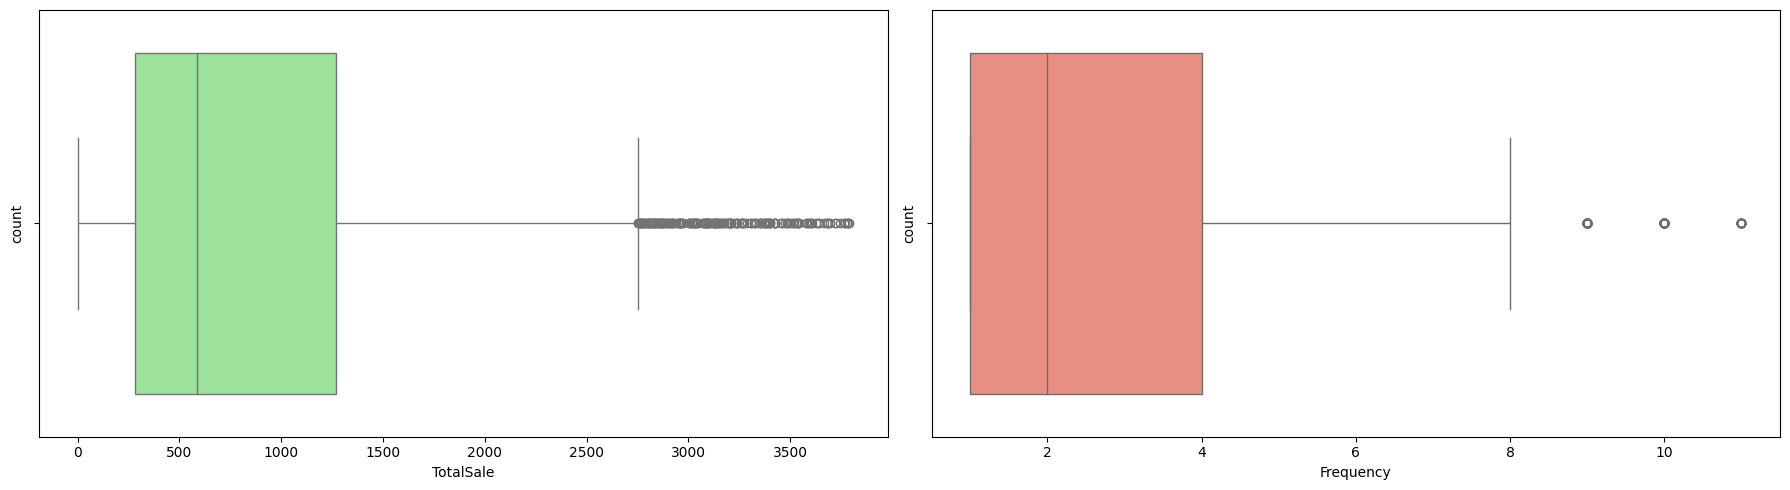

In [114]:
# plotting the non-outlier data 

plt.figure(figsize=(18, 5))

plt.subplot(121)
sns.boxplot(x=non_outliers['TotalSale'], color='lightgreen')
plt.ylabel('count')

plt.subplot(122)
sns.boxplot(x=non_outliers['Frequency'], color='salmon')
plt.ylabel('count')

plt.tight_layout()
plt.show()

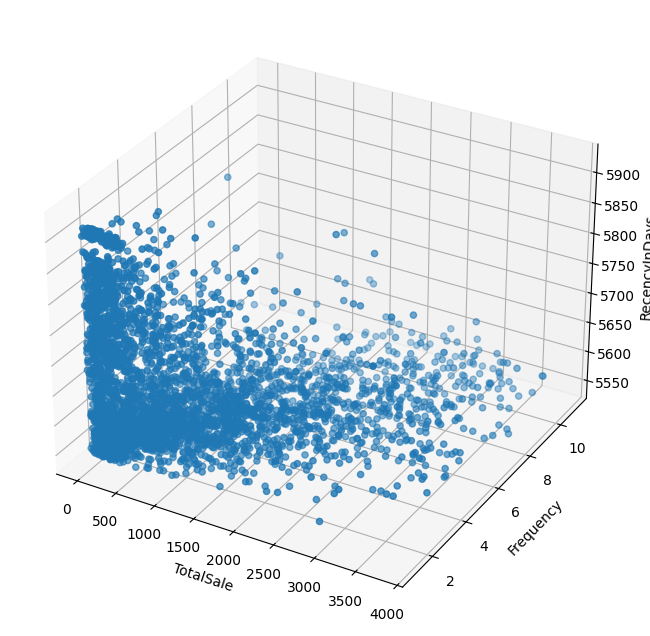

In [124]:
# making a 3D plot of the data

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(non_outliers['TotalSale'], non_outliers['Frequency'], non_outliers['RecencyInDays'])

ax.set_xlabel('TotalSale')
ax.set_ylabel('Frequency')
ax.set_zlabel('RecencyInDays')


plt.show()

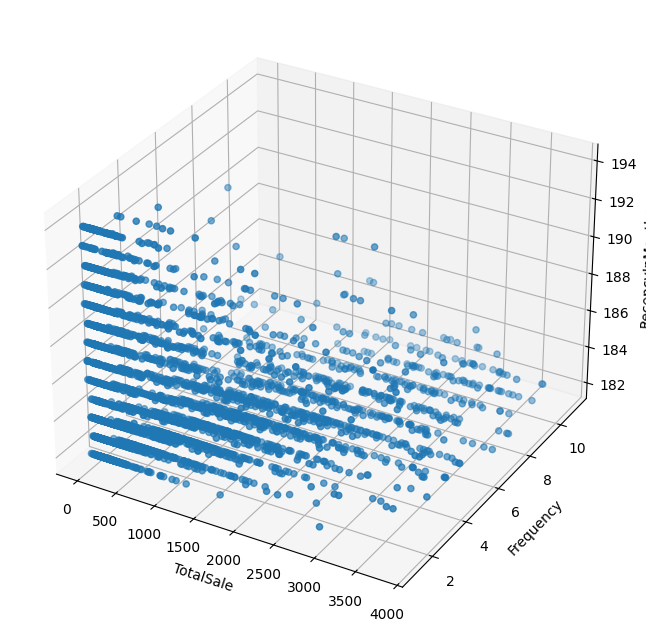

In [125]:
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(non_outliers['TotalSale'], non_outliers['Frequency'], non_outliers['RecencyInMonths'])

ax.set_xlabel('TotalSale')
ax.set_ylabel('Frequency')
ax.set_zlabel('RecencyInMonths')


plt.show()

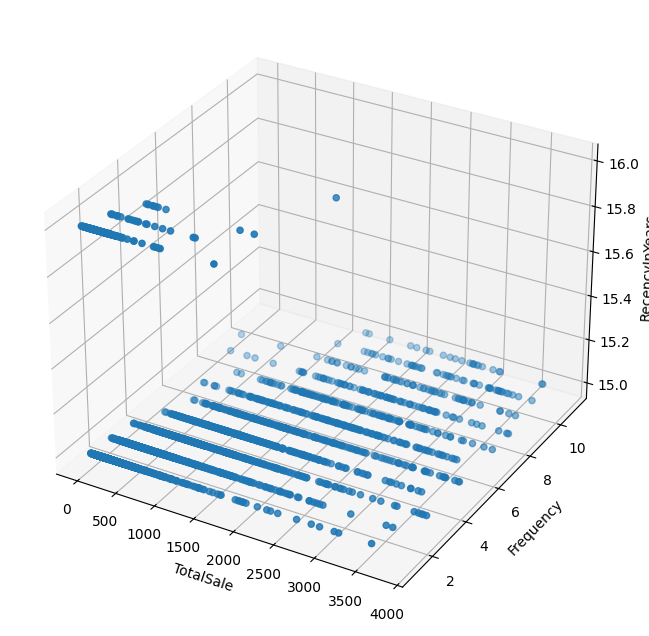

In [ ]:
# making a 3D plot of the data

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(non_outliers['TotalSale'], non_outliers['Frequency'], non_outliers['RecencyInYears'])  # as you can see, we have much higher sale and frequency in 15 year back compared to the 16 year back

ax.set_xlabel('TotalSale')
ax.set_ylabel('Frequency')
ax.set_zlabel('RecencyInYears')


plt.show()